# 🎮 Exploratory Data Analysis — Steam Game Recommendations

This notebook explores the Steam dataset to understand:
1. Dataset scale and structure
2. Interaction sparsity (critical for CF)
3. Distribution of engagement signals (reviews, playtime)
4. Game metadata coverage (tags, genres)
5. Review sentiment and Wilson score distribution

In [1]:
import sys
sys.path.insert(0, '..')

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

logging.basicConfig(level=logging.INFO)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

from src.data.loader import load_and_prepare
from src.data.features import compute_engagement_scores
from src.models.wilson_score import wilson_lower_bound

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Prepare Data

In [2]:
data = load_and_prepare('../data/raw')
games = data['games']
train = data['train']
test = data['test']

print(f"Games:  {len(games):>12,}")
print(f"Users:  {len(data['user_to_idx']):>12,}")
print(f"Train:  {len(train):>12,}")
print(f"Test:   {len(test):>12,}")
print(f"\nGames columns: {list(games.columns)}")
print(f"Train columns: {list(train.columns)}")

INFO:src.data.loader:Loading games.csv...
INFO:src.data.loader:  → 50,872 games, columns: ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']
INFO:src.data.loader:Loading games_metadata.json...
INFO:src.data.loader:  → metadata for 50,872 games
INFO:src.data.loader:Loading recommendations.csv...
INFO:src.data.loader:  → 41,154,794 recommendations
INFO:src.data.loader:Loading users.csv...
INFO:src.data.loader:  → 14,306,064 users
INFO:src.data.loader:  → 49,628/50,872 games have tags
INFO:src.data.loader:  → converged after 6 iterations
INFO:src.data.loader:Filtered interactions: 41,154,794 → 22,286,984 (54.2% retained)
INFO:src.data.loader:  → 1,905,448 users, 22,676 games remaining
INFO:src.data.loader:Train: 18,397,299 | Test: 3,889,685
INFO:src.data.loader:Final dataset: 22,676 games, 1,905,448 users, 18,397,299 train + 3,889,685 test interactions


Games:        22,676
Users:     1,905,448
Train:    18,397,299
Test:      3,889,685

Games columns: ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck', 'tags', 'description']
Train columns: ['app_id', 'helpful', 'funny', 'date', 'is_recommended', 'hours', 'user_id', 'review_id']


## 2. Interaction Matrix Sparsity

Sparsity is the core challenge of collaborative filtering. Most users have reviewed only a tiny fraction of available games.

In [3]:
n_users = len(data['user_to_idx'])
n_games = len(data['game_to_idx'])
n_interactions = len(train)
sparsity = 1 - (n_interactions / (n_users * n_games))

print(f"Interaction matrix: {n_users:,} users × {n_games:,} games")
print(f"Non-zero entries:   {n_interactions:,}")
print(f"Possible entries:   {n_users * n_games:,}")
print(f"Sparsity:           {sparsity:.6%}")
print(f"\n→ Only {(1-sparsity)*100:.4f}% of the matrix is filled.")
print(f"→ This is why we need content-based filtering for cold-start.")

Interaction matrix: 1,905,448 users × 22,666 games
Non-zero entries:   18,397,299
Possible entries:   43,188,884,368
Sparsity:           99.957403%

→ Only 0.0426% of the matrix is filled.
→ This is why we need content-based filtering for cold-start.


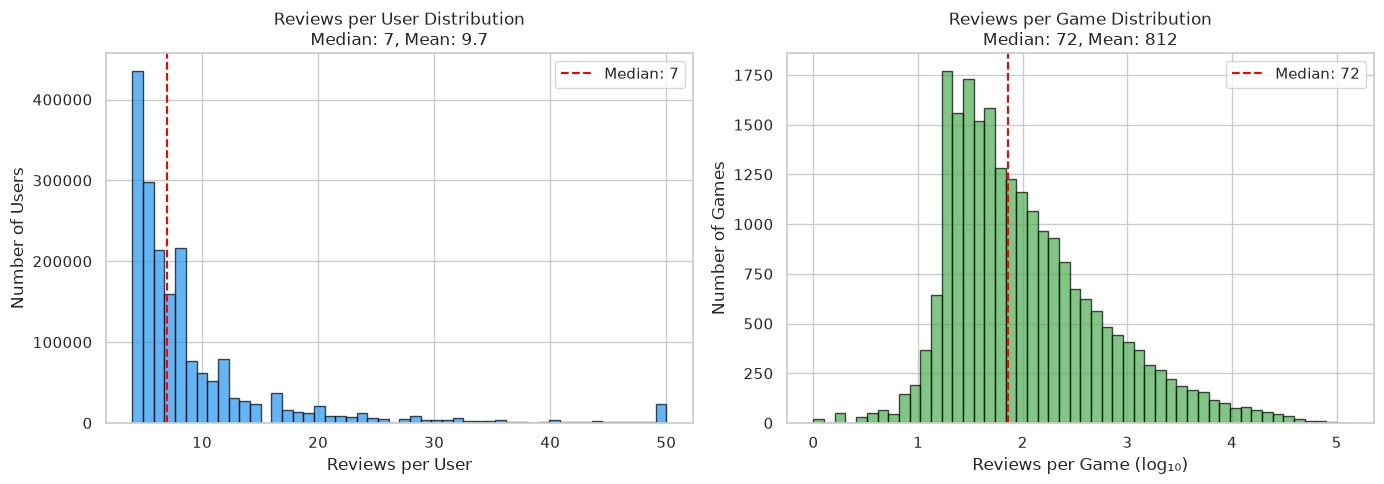

In [4]:
# Distribution of reviews per user and per game
reviews_per_user = train.groupby('user_id').size()
reviews_per_game = train.groupby('app_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews per user
axes[0].hist(reviews_per_user.clip(upper=50), bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
axes[0].set_xlabel('Reviews per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title(f'Reviews per User Distribution\nMedian: {reviews_per_user.median():.0f}, Mean: {reviews_per_user.mean():.1f}')
axes[0].axvline(reviews_per_user.median(), color='red', linestyle='--', label=f'Median: {reviews_per_user.median():.0f}')
axes[0].legend()

# Reviews per game
axes[1].hist(np.log10(reviews_per_game), bins=50, edgecolor='black', alpha=0.7, color='#4CAF50')
axes[1].set_xlabel('Reviews per Game (log₁₀)')
axes[1].set_ylabel('Number of Games')
axes[1].set_title(f'Reviews per Game Distribution\nMedian: {reviews_per_game.median():.0f}, Mean: {reviews_per_game.mean():.0f}')
axes[1].axvline(np.log10(reviews_per_game.median()), color='red', linestyle='--', label=f'Median: {reviews_per_game.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/sparsity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Engagement Signals: Playtime & Review Sentiment

INFO:src.data.features:Engagement scores: mean=3.62, median=3.81, max=7.91


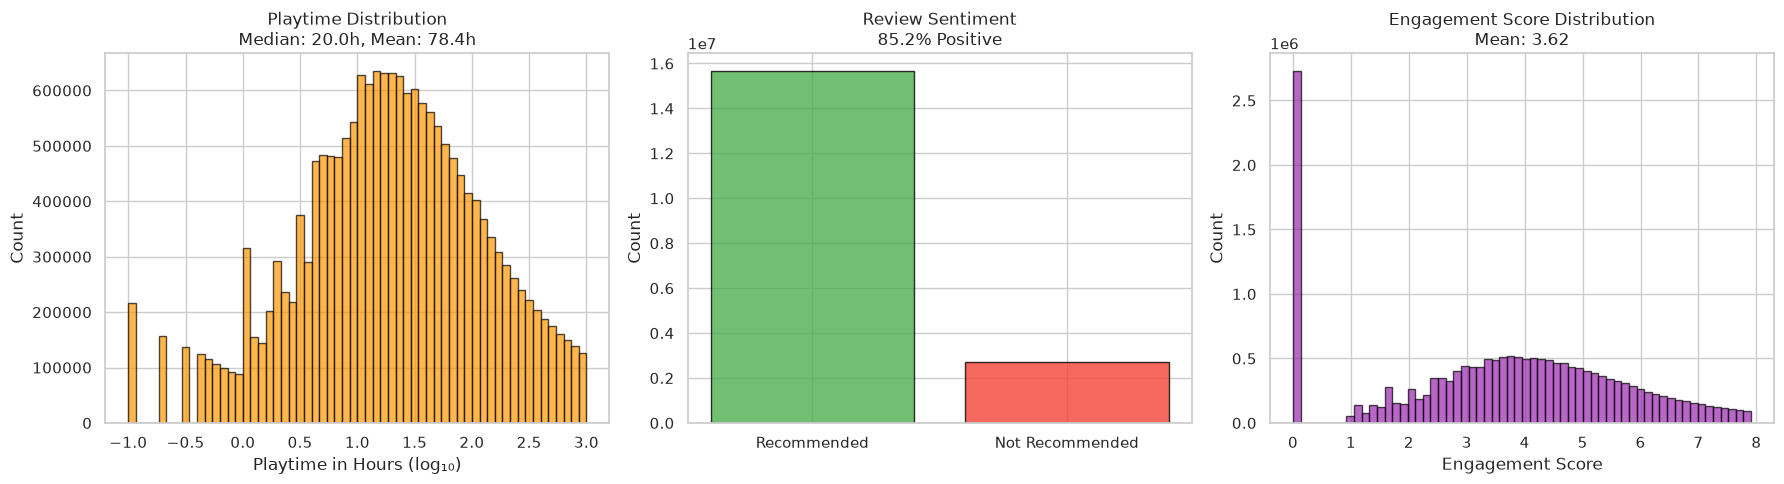

In [5]:
train_with_scores = compute_engagement_scores(train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Playtime distribution (log scale)
playtime = train_with_scores['hours'].clip(lower=0.1)
axes[0].hist(np.log10(playtime), bins=60, edgecolor='black', alpha=0.7, color='#FF9800')
axes[0].set_xlabel('Playtime in Hours (log₁₀)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Playtime Distribution\nMedian: {train["hours"].median():.1f}h, Mean: {train["hours"].mean():.1f}h')

# Recommendation ratio
rec_counts = train_with_scores['is_recommended'].value_counts()
axes[1].bar(['Recommended', 'Not Recommended'], rec_counts.values, 
            color=['#4CAF50', '#f44336'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Count')
total = rec_counts.sum()
pos_pct = rec_counts.get(True, 0) / total * 100
axes[1].set_title(f'Review Sentiment\n{pos_pct:.1f}% Positive')

# Engagement score distribution
axes[2].hist(train_with_scores['engagement_score'].clip(upper=20), bins=60, 
             edgecolor='black', alpha=0.7, color='#9C27B0')
axes[2].set_xlabel('Engagement Score')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Engagement Score Distribution\nMean: {train_with_scores["engagement_score"].mean():.2f}')

plt.tight_layout()
plt.savefig('../assets/engagement_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Game Metadata — Tags & Genres

/tmp/ipykernel_274826/70141448.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tags_df, x='Count', y='Tag', ax=ax, palette='viridis')


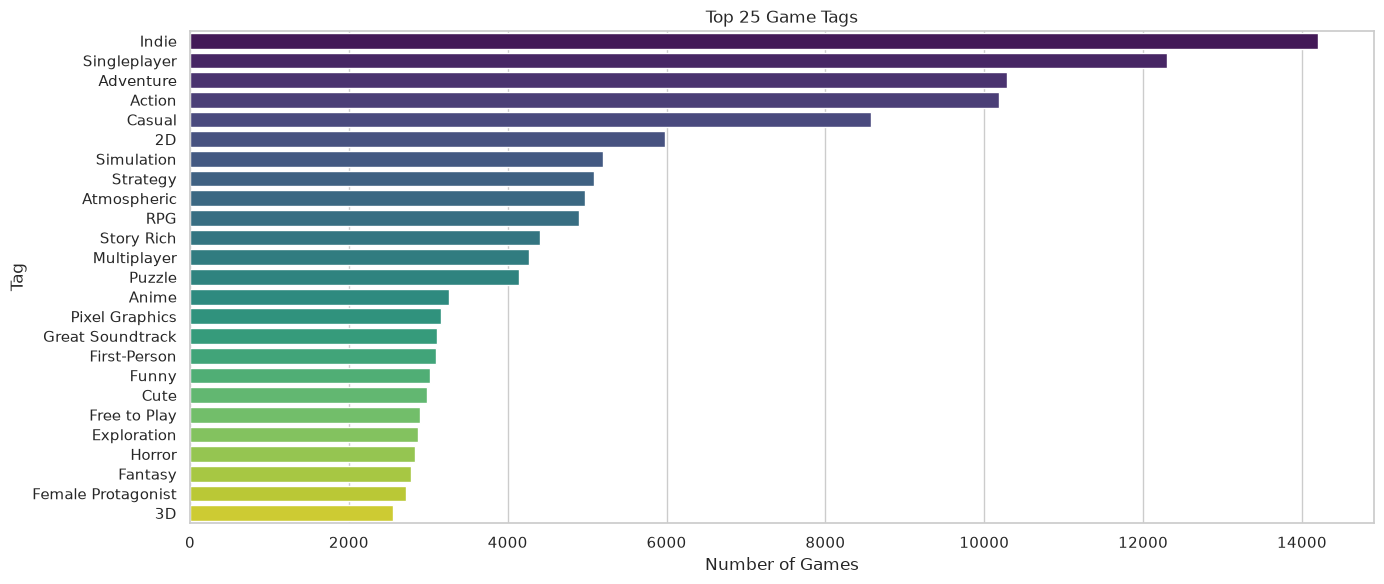


Total unique tags: 441
Games with tags:   22,102/22,676


In [6]:
# Explode tags and count frequencies
all_tags = []
for tags in games['tags'].dropna():
    for tag in str(tags).split(','):
        tag = tag.strip()
        if tag:
            all_tags.append(tag)

tag_counts = Counter(all_tags)
top_tags = tag_counts.most_common(25)

fig, ax = plt.subplots(figsize=(14, 6))
tags_df = pd.DataFrame(top_tags, columns=['Tag', 'Count'])
sns.barplot(data=tags_df, x='Count', y='Tag', ax=ax, palette='viridis')
ax.set_title('Top 25 Game Tags')
ax.set_xlabel('Number of Games')
plt.tight_layout()
plt.savefig('../assets/top_tags.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal unique tags: {len(tag_counts):,}")
print(f"Games with tags:   {(games['tags'].str.len() > 0).sum():,}/{len(games):,}")

## 5. Wilson Score — Quality vs Popularity

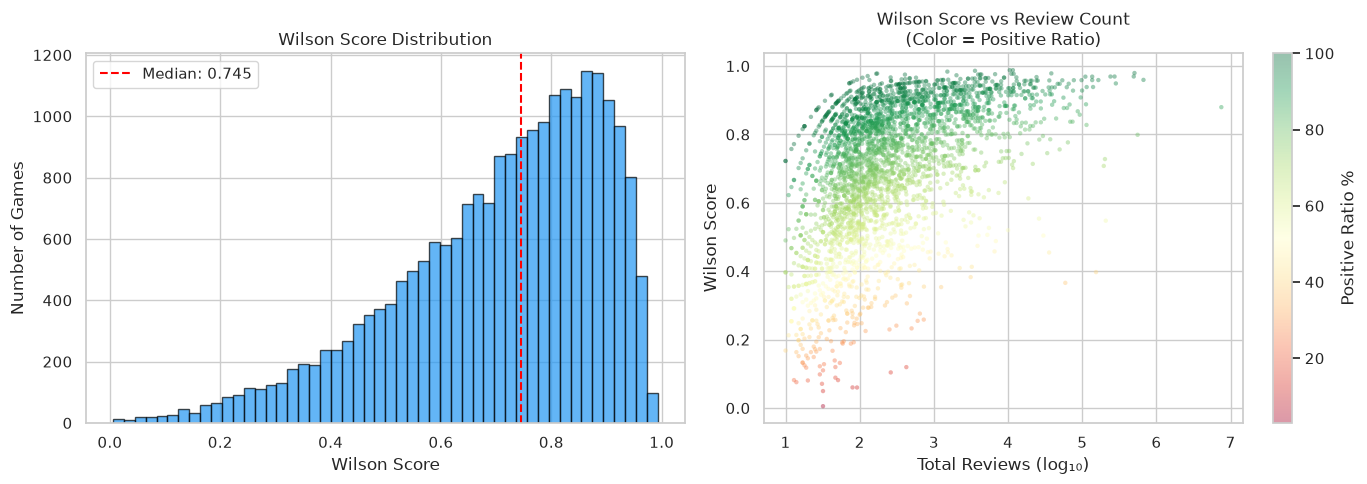

In [7]:
# Compute Wilson scores
games_ws = games.copy()
total_reviews = games_ws['user_reviews'].fillna(0).astype(float)
pos_ratio = games_ws['positive_ratio'].fillna(50).astype(float) / 100.0
pos_reviews = (total_reviews * pos_ratio).round()

games_ws['wilson_score'] = wilson_lower_bound(pos_reviews.values, total_reviews.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wilson score distribution
axes[0].hist(games_ws['wilson_score'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
axes[0].set_xlabel('Wilson Score')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Wilson Score Distribution')
axes[0].axvline(games_ws['wilson_score'].median(), color='red', linestyle='--', 
                label=f'Median: {games_ws["wilson_score"].median():.3f}')
axes[0].legend()

# Wilson score vs total reviews (shows how Wilson penalizes low-evidence games)
sample = games_ws[games_ws['user_reviews'] > 0].sample(min(3000, len(games_ws)), random_state=42)
scatter = axes[1].scatter(
    np.log10(sample['user_reviews'].clip(lower=1)), 
    sample['wilson_score'],
    c=sample['positive_ratio'], cmap='RdYlGn', 
    alpha=0.4, s=10, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[1], label='Positive Ratio %')
axes[1].set_xlabel('Total Reviews (log₁₀)')
axes[1].set_ylabel('Wilson Score')
axes[1].set_title('Wilson Score vs Review Count\n(Color = Positive Ratio)')

plt.tight_layout()
plt.savefig('../assets/wilson_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Example: Wilson score in action
# Compare a game with few perfect reviews vs a game with many mostly-positive reviews
print("Wilson Score — Why it matters:")
print("=" * 60)
examples = [
    ("Game A", 3, 3),
    ("Game B", 10, 10),
    ("Game C", 50, 55),
    ("Game D", 950, 1000),
    ("Game E", 9500, 10000),
]
for name, pos, total in examples:
    raw_ratio = pos / total
    wilson = wilson_lower_bound(pos, total)
    print(f"{name}: {pos}/{total} positive ({raw_ratio:.0%}) → Wilson = {wilson:.4f}")

print("\n→ Game A (3/3 = 100%) has a LOWER Wilson score than Game D (950/1000 = 95%)")
print("  because we have less statistical confidence in Game A's true quality.")

Wilson Score — Why it matters:
Game A: 3/3 positive (100%) → Wilson = 0.4385
Game B: 10/10 positive (100%) → Wilson = 0.7225
Game C: 50/55 positive (91%) → Wilson = 0.8042
Game D: 950/1000 positive (95%) → Wilson = 0.9347
Game E: 9500/10000 positive (95%) → Wilson = 0.9456

→ Game A (3/3 = 100%) has a LOWER Wilson score than Game D (950/1000 = 95%)
  because we have less statistical confidence in Game A's true quality.


## 6. Summary Statistics

In [9]:
# User activity levels (for hybrid weighting decisions)
user_review_counts = train.groupby('user_id').size()

cold = (user_review_counts < 3).sum()
warm = ((user_review_counts >= 3) & (user_review_counts < 10)).sum()
active = (user_review_counts >= 10).sum()
total_users = len(user_review_counts)

print("User Activity Level Distribution")
print("=" * 45)
print(f"Cold   (< 3 reviews):  {cold:>10,} ({cold/total_users:.1%})")
print(f"Warm   (3-9 reviews):  {warm:>10,} ({warm/total_users:.1%})")
print(f"Active (10+ reviews):  {active:>10,} ({active/total_users:.1%})")
print(f"{'─' * 45}")
print(f"Total:                 {total_users:>10,}")
print(f"\n→ {cold/total_users:.1%} of users are cold-start — this is why the content-based")
print(f"  fallback in our hybrid system is essential.")

User Activity Level Distribution
Cold   (< 3 reviews):           0 (0.0%)
Warm   (3-9 reviews):   1,399,411 (73.4%)
Active (10+ reviews):     506,037 (26.6%)
─────────────────────────────────────────────
Total:                  1,905,448

→ 0.0% of users are cold-start — this is why the content-based
  fallback in our hybrid system is essential.


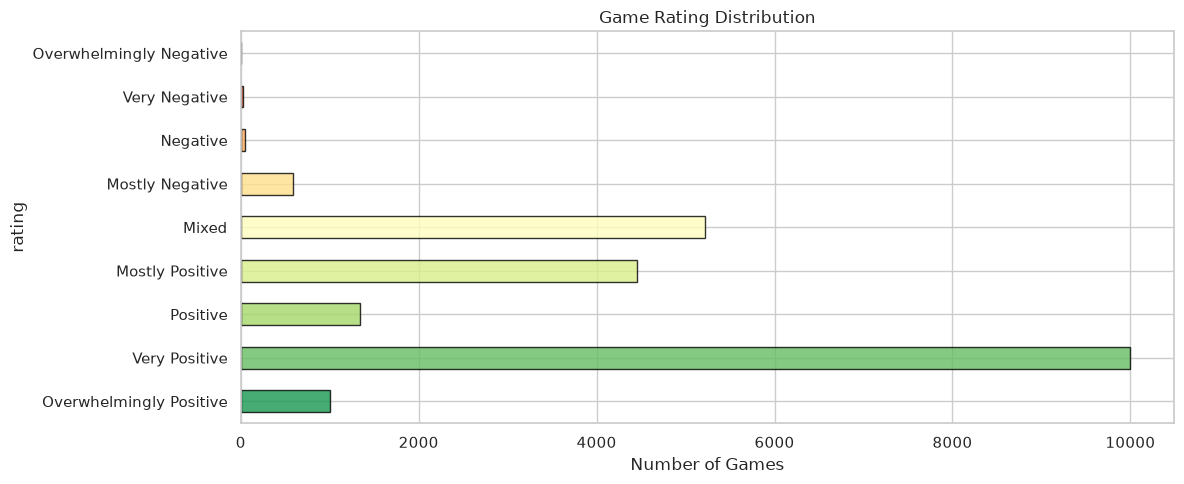

In [10]:
# Rating distribution
if 'rating' in games.columns:
    rating_order = ['Overwhelmingly Positive', 'Very Positive', 'Positive', 
                    'Mostly Positive', 'Mixed', 'Mostly Negative', 
                    'Negative', 'Very Negative', 'Overwhelmingly Negative']
    rating_counts = games['rating'].value_counts()
    # Reindex to get proper order, dropping any not present
    rating_counts = rating_counts.reindex([r for r in rating_order if r in rating_counts.index])
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = sns.color_palette('RdYlGn_r', len(rating_counts))
    rating_counts.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Number of Games')
    ax.set_title('Game Rating Distribution')
    plt.tight_layout()
    plt.savefig('../assets/rating_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Dataset: {len(games):,} games, {total_users:,} users, {len(train)+len(test):,} interactions")
print(f"Sparsity: {1 - len(train)/(n_users*n_games):.4%}")
print(f"Unique tags: {len(tag_counts):,} across {(games['tags'].str.len() > 0).sum():,} games")
print(f"Positive review rate: {pos_pct:.1f}%")
print(f"Cold-start users: {cold/total_users:.1%}")
print(f"\nKey insights:")
print(f"  • Extremely sparse matrix → SVD is appropriate (not full matrix factorization)")
print(f"  • {cold/total_users:.1%} cold-start users → content-based fallback is essential")
print(f"  • Rich tag metadata ({len(tag_counts):,} unique tags) → strong content features")
print(f"  • Skewed playtime → log-transform in engagement score is justified")


EDA SUMMARY
Dataset: 22,676 games, 1,905,448 users, 22,286,984 interactions
Sparsity: 99.9574%
Unique tags: 441 across 22,102 games
Positive review rate: 85.2%
Cold-start users: 0.0%

Key insights:
  • Extremely sparse matrix → SVD is appropriate (not full matrix factorization)
  • 0.0% cold-start users → content-based fallback is essential
  • Rich tag metadata (441 unique tags) → strong content features
  • Skewed playtime → log-transform in engagement score is justified
